# Notebook 11: Weather Features (Phase 17)

Joins monthly Staten Island weather onto the 7-Day OTP feature series and explores
how weather relates to on-time performance. The join logic lives in
`scripts/weather_features.py` (unit-tested); this notebook is the analysis narrative.


In [1]:
import sys
sys.path.insert(0, '..')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scripts.fetch_weather_data import WEATHER_COLUMNS
from scripts.weather_features import build, OPERATIONAL_CSV, ORACLE_CSV

## Two framings

**Operational**: a feature row for month *t* carries the weather of month *t*, known
when the *t+1* forecast is made. A real forecast input.

**Oracle**: a feature row for month *t* carries the weather of its target month *t+1*.
Not a forecast; it measures how much of the OTP the base model misses is explainable by
weather, given foreknowledge. The February 2026 snowstorm is an oracle test.


In [2]:
operational, oracle = build()
operational.to_csv(OPERATIONAL_CSV, index=False)
oracle.to_csv(ORACLE_CSV, index=False)
print('operational', operational.shape, '| oracle', oracle.shape)
print('weather NaNs:', int(operational[WEATHER_COLUMNS].isna().sum().sum()),
      int(oracle[WEATHER_COLUMNS].isna().sum().sum()))

operational (239, 34) | oracle (239, 34)
weather NaNs: 0 0


## Alignment check: February 2026

The single most important correctness point. Operational should put February's snow on
February's own row; oracle should put it on January's row (whose target is February).


In [3]:
cols = ['Month', 'On-Time Performance', 'total_snowfall_cm']
print('OPERATIONAL, Feb 2026 (own weather):')
print(operational.loc[operational['Month']=='2026-02-01', cols].to_string(index=False))
print()
print('ORACLE, Jan 2026 (weather of target month Feb):')
print(oracle.loc[oracle['Month']=='2026-01-01', cols + ['Next_Month_OTP']].to_string(index=False))
assert operational.loc[operational['Month']=='2026-02-01','total_snowfall_cm'].iloc[0] > 25
assert oracle.loc[oracle['Month']=='2026-01-01','total_snowfall_cm'].iloc[0] > 25

OPERATIONAL, Feb 2026 (own weather):
     Month  On-Time Performance  total_snowfall_cm
2026-02-01                 0.94              30.45

ORACLE, Jan 2026 (weather of target month Feb):
     Month  On-Time Performance  total_snowfall_cm  Next_Month_OTP
2026-01-01                0.964              30.45            0.94


## How does weather relate to OTP?

Correlation of each month-*t* weather feature with same-month OTP and with next-month OTP.


                       same_month_OTP  next_month_OTP
total_snowfall_cm               0.012           0.109
max_daily_snowfall_cm          -0.034           0.122
snow_days                       0.037           0.176
total_precip_mm                 0.103           0.040
mean_temp_c                     0.150          -0.098
min_temp_c                      0.130          -0.105
freezing_days                   0.020           0.205
max_wind_kmh                    0.046           0.122


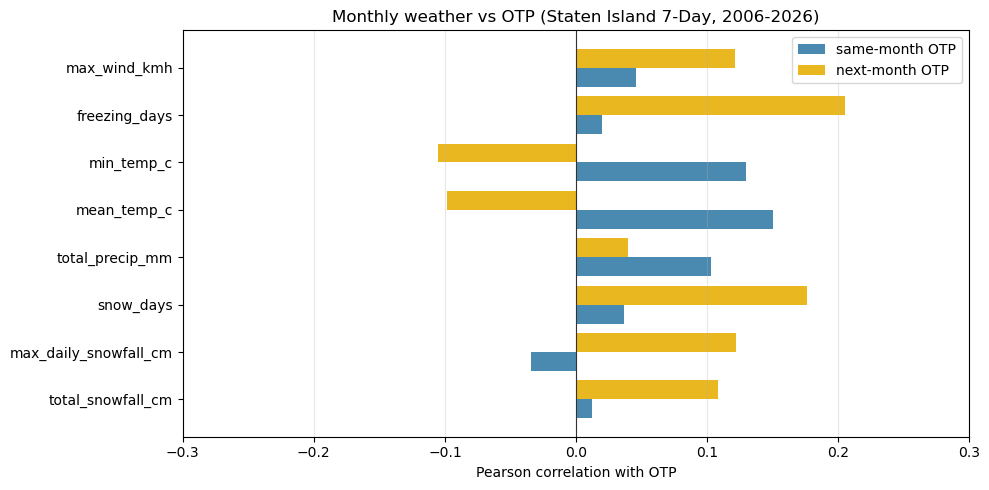

In [4]:
op = operational.copy()
op['otp_pct'] = op['On-Time Performance'] * 100
op['next_pct'] = pd.to_numeric(op['Next_Month_OTP'], errors='coerce') * 100
same = op[WEATHER_COLUMNS].corrwith(op['otp_pct'])
nextm = op[WEATHER_COLUMNS].corrwith(op['next_pct'])
corr = pd.DataFrame({'same_month_OTP': same, 'next_month_OTP': nextm})
print(corr.round(3).to_string())

fig, ax = plt.subplots(figsize=(10, 5))
y = np.arange(len(WEATHER_COLUMNS))
ax.barh(y - 0.2, corr['same_month_OTP'], height=0.4, label='same-month OTP', color='#4a8ab0')
ax.barh(y + 0.2, corr['next_month_OTP'], height=0.4, label='next-month OTP', color='#e9b820')
ax.set_yticks(y); ax.set_yticklabels(WEATHER_COLUMNS)
ax.axvline(0, color='#333', linewidth=0.8)
ax.set_xlabel('Pearson correlation with OTP'); ax.set_xlim(-0.3, 0.3)
ax.set_title('Monthly weather vs OTP (Staten Island 7-Day, 2006-2026)')
ax.legend(); ax.grid(axis='x', alpha=0.3)
fig.tight_layout()
fig.savefig('../outputs/figures/weather_otp_correlation.png', dpi=200, bbox_inches='tight')
plt.show()

## Finding

Linear correlations between monthly weather and OTP are weak: no feature exceeds
|r| = 0.21, and same-month snowfall is essentially uncorrelated with same-month OTP.
This says the SIR is resilient to typical monthly weather, and that any weather effect
is nonlinear and confined to extreme events rather than a smooth monthly relationship.

That is the motivation for the controlled experiment (Phase 23): a linear view understates
what a tree model might extract from rare shocks such as February 2026, while also warning
that the operational forecasting value of weather may be small. Both are tested next.
